In [1]:
import numpy as np
import matplotlib.pyplot as plt

# plt.style.use('ggplot')


## plot $\cos^2(2\pi f n)$ as a function of $f$ for different $N$

In [2]:
f = np.linspace(0,0.5, 10000)
# f = np.linspace(0,0.5, 1000, endpoint=False)[1:]
N = 100

In [3]:
sum = 0
for n in range(N):
    sum = sum + (np.cos(2*np.pi*f*n))**2

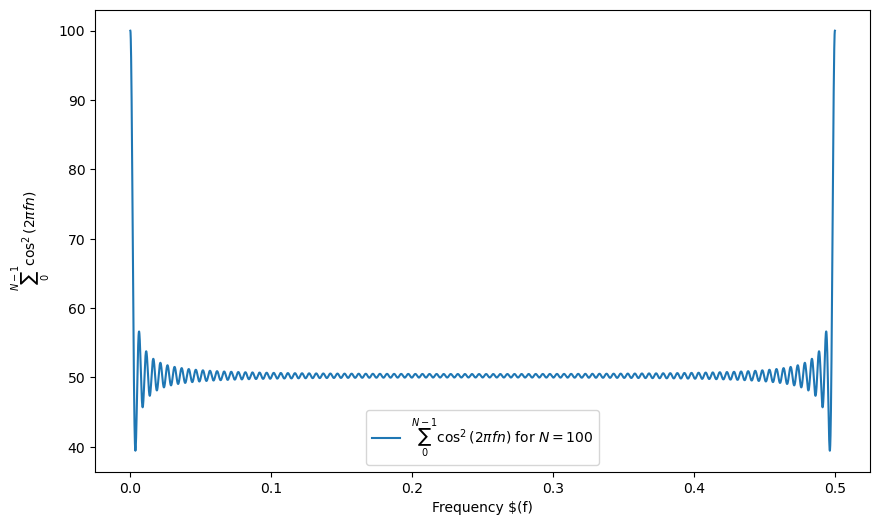

In [4]:
plt.figure(figsize=(10,6)) #dpi=150,
plt.plot(f, sum)
plt.legend([r"$\sum_0^{N-1} \cos^2(2\pi f n)$ for $N = 100$"])
plt.ylabel(r"$\sum_0^{N-1} \cos^2(2\pi f n)$")
plt.xlabel(r"Frequency $(f)")
plt.show()

## plot a few realizations of the function to be maximized

In [5]:
N = 10
f = np.linspace(0,0.5, 1000)

mu =  0
sigma = np.sqrt(0.01) # mean and standard deviation
# w = np.random.normal(mu, sigma)

In [6]:
sum1 = 0
for n in range(N):
    w1 = np.random.normal(mu, sigma)
    x = np.cos(2*np.pi*0.25*n) + w1
    sum1 = sum1 + x*(np.cos(2*np.pi*f*n))

In [7]:
sum2 = 0
for n in range(N):
    w2 = np.random.normal(mu, sigma)
    x = np.cos(2*np.pi*0.25*n) + w2
    sum2 = sum2 + x*(np.cos(2*np.pi*f*n))

In [8]:
sum3 = 0
for n in range(N):
    w3 = np.random.normal(mu, sigma)
    x = np.cos(2*np.pi*0.25*n) + w3
    sum3 = sum3 + x*(np.cos(2*np.pi*f*n))

In [9]:
sum4 = 0
for n in range(N):
    w4 = np.random.normal(mu, sigma)
    x = np.cos(2*np.pi*0.25*n) + w4
    sum4 = sum4 + x*(np.cos(2*np.pi*f*n))

Text(0.5, 0, 'Frequency $(f)$')

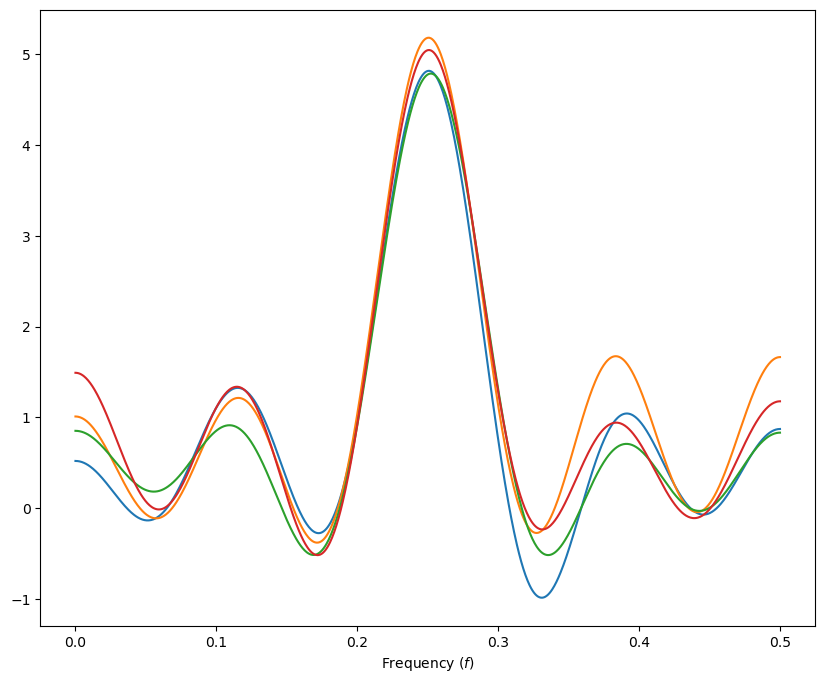

In [10]:
plt.figure(figsize=(10,8)) #dpi=150,
plt.plot(f, sum1)
plt.plot(f, sum2)
plt.plot(f, sum3)
plt.plot(f, sum4)
plt.xlabel(r"Frequency $(f)$")


## Numerical method to obtain the ML estimate

In [11]:
start = 0
stop = 0.5
num_step = 2000#0.5*0.001

# f_space = np.linspace(start, stop, num_step)
f_space = np.linspace(start, stop, num_step, endpoint=False)[1:]

N = 10
mu =  0
sigma = np.sqrt(0.01) # mean and standard deviation

In [12]:
# Searching f that maximize the objective function (for single realization)
max_sum = 0
best_f = 0
w_array = np.random.normal(mu, sigma,[N])
for f in f_space:
    sum = 0
    for n in range(N):
        w = w_array[n]
        x = np.cos(2*np.pi*0.25*n) + w
        sum = sum + x*(np.cos(2*np.pi*f*n))
    # print(sum)
    if sum > max_sum:
        max_sum = sum
        best_f = f

print("f that maximize the objective function (for single realization) = ",best_f)


f that maximize the objective function (for single realization) =  0.2515


In [13]:
# Searching f that maximize the objective function for M = 5000 realizations
M = 5000
def search_f_maximize():
    max_sum = 0
    best_f = 0
    w_array = np.random.normal(mu, sigma,[N])
    for f in f_space:
        sum = 0
        for n in range(N):
            w = w_array[n]
            x = np.cos(2*np.pi*0.25*n) + w # calculate x[n]
            sum = sum + x*(np.cos(2*np.pi*f*n)) # calculate sum = sigma (x[n] * cos(2pi.f.n))
        if sum > max_sum:
            max_sum = sum
            best_f = f
    return best_f

f = []
for i in range(M):
    f.append(search_f_maximize())

In [14]:
f= np.array(f)

(array([  6.,   2.,   1.,  10.,  20.,  16.,  32.,  39., 109.,  91., 106.,
        131., 157., 350., 213., 248., 247., 542., 276., 306., 263., 289.,
        466., 208., 192., 160., 217.,  81.,  70.,  40.,  39.,  40.,  11.,
         10.,   3.,   5.,   0.,   1.,   2.,   1.]),
 array([0.24425   , 0.24455625, 0.2448625 , 0.24516875, 0.245475  ,
        0.24578125, 0.2460875 , 0.24639375, 0.2467    , 0.24700625,
        0.2473125 , 0.24761875, 0.247925  , 0.24823125, 0.2485375 ,
        0.24884375, 0.24915   , 0.24945625, 0.2497625 , 0.25006875,
        0.250375  , 0.25068125, 0.2509875 , 0.25129375, 0.2516    ,
        0.25190625, 0.2522125 , 0.25251875, 0.252825  , 0.25313125,
        0.2534375 , 0.25374375, 0.25405   , 0.25435625, 0.2546625 ,
        0.25496875, 0.255275  , 0.25558125, 0.2558875 , 0.25619375,
        0.2565    ]),
 <BarContainer object of 40 artists>)

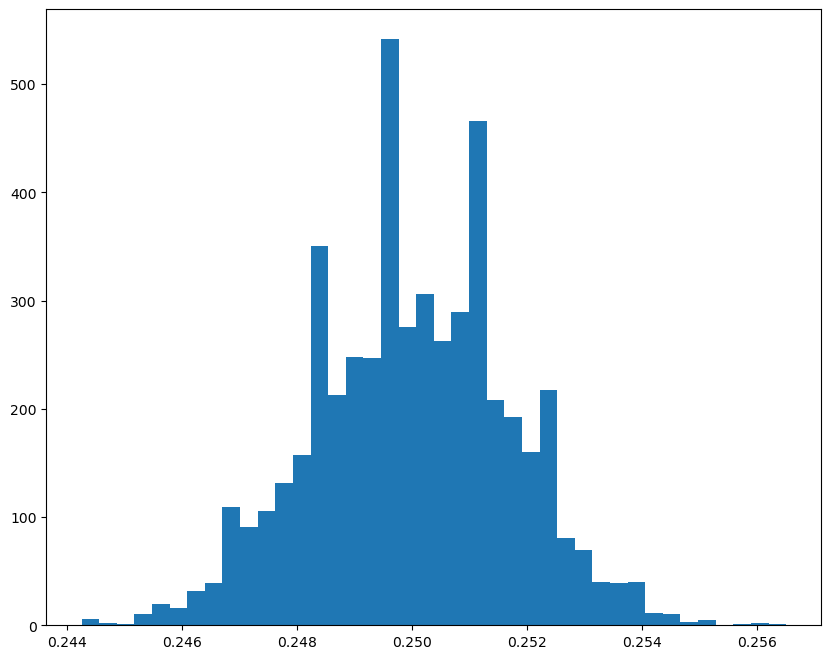

In [15]:
plt.figure(figsize=(10,8)) #dpi=150,
plt.hist(f,bins=40)
# plt.ylabel(r"$\hat f}$ objective")
# plt.xlabel(r"Frequency $(f)$")
# plt.show()